In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train = pd.read_csv(PROCESSED_DIR / "train_data_engineered.csv")
test  = pd.read_csv(PROCESSED_DIR / "test_data_engineered.csv")

train["DateTime"] = pd.to_datetime(train["DateTime"])
test["DateTime"]  = pd.to_datetime(test["DateTime"])

train = train.sort_values("DateTime").reset_index(drop=True)
test  = test.sort_values("DateTime").reset_index(drop=True)


In [2]:
target_cols = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

drop_cols = ['DateTime'] + target_cols
feature_cols = [c for c in train.columns if c not in drop_cols]

print(len(feature_cols), "features")
print(feature_cols[:10])


124 features
['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'dayofweek']


In [3]:
from typing import Tuple
import pandas as pd

def make_supervised(df: pd.DataFrame,
                    target_col: str,
                    horizon: int,
                    feature_cols: list
                   ) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """
    df: train OR test (already sorted by DateTime)
    target_col: one of the pollutant columns
    horizon: prediction horizon in hours (1,6,12,24)
    feature_cols: list of feature columns
    """
    data = df.copy()

    # future target y(t+h)
    data["y_target"] = data[target_col].shift(-horizon)

    # naive baseline: ŷ(t+h) = y(t)
    data["y_naive"] = data[target_col]

    # drop rows where we don't have future target
    data = data.dropna(subset=["y_target", "y_naive"])

    X = data[feature_cols]
    y = data["y_target"]
    y_naive = data["y_naive"]
    return X, y, y_naive

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import math

pollutants = target_cols
horizons = [1, 6, 12, 24]

results = []

for target in pollutants:
    for h in horizons:
        # build supervised datasets from engineered train/test
        X_train, y_train, y_naive_train = make_supervised(train, target, h, feature_cols)
        X_test,  y_test,  y_naive_test  = make_supervised(test,  target, h, feature_cols)
        
        # -------- Naive baseline --------
        rmse_naive = math.sqrt(mean_squared_error(y_test, y_naive_test))
        
        # -------- Ridge Regression (with scaling) --------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)
        
        ridge = Ridge(alpha=1.0, random_state=0)
        ridge.fit(X_train_scaled, y_train)
        y_pred_ridge = ridge.predict(X_test_scaled)
        rmse_ridge = math.sqrt(mean_squared_error(y_test, y_pred_ridge))
        
        # -------- Random Forest --------
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=0,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
        
        results.append({
            'target': target,
            'horizon_h': h,
            'RMSE_naive': rmse_naive,
            'RMSE_ridge': rmse_ridge,
            'RMSE_random_forest': rmse_rf
        })

results_df = pd.DataFrame(results)
results_df

,target,horizon_h,RMSE_naive,RMSE_ridge,RMSE_random_forest
0,CO(GT),1,0.560437,0.485085,0.486818
1,CO(GT),6,1.278812,0.809843,0.874250
2,CO(GT),12,1.277548,0.922950,0.978547
3,CO(GT),24,0.914224,0.918626,1.015565
4,NMHC(GT),1,0.559673,0.548689,0.461058
5,NMHC(GT),6,1.441481,0.626198,0.556663
6,NMHC(GT),12,1.346855,0.501280,0.498977
7,NMHC(GT),24,0.000000,0.480673,0.574436
8,C6H6(GT),1,0.484218,0.491972,0.386369
9,C6H6(GT),6,1.096303,0.875476,0.846811


In [5]:
results_path = PROCESSED_DIR / "regression_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved results to:", results_path)

Saved results to: C:\Users\alexs\OneDrive\UNSW\COMP9417\Group\9417The-Stuff-of-Legend\data\processed\regression_results.csv


In [6]:
# average RMSE per model (across pollutants + horizons)
print("Mean RMSE (overall):")
for col, name in [("RMSE_naive", "Naive"),
                  ("RMSE_ridge", "Ridge"),
                  ("RMSE_random_forest", "Random Forest")]:
    print(f"{name:<15}: {results_df[col].mean():.4f}")

Mean RMSE (overall):
Naive          : 1.0233
Ridge          : 0.7493
Random Forest  : 0.7739


In [10]:
horizon_summary = results_df.groupby("horizon_h")[[
    "RMSE_naive", "RMSE_ridge", "RMSE_random_forest"
]].mean()
print(horizon_summary)


           RMSE_naive  RMSE_ridge  RMSE_random_forest
horizon_h                                            
1            0.562642    0.525170            0.499832
6            1.389547    0.821398            0.830589
12           1.370951    0.830158            0.881782
24           0.769899    0.820330            0.883273


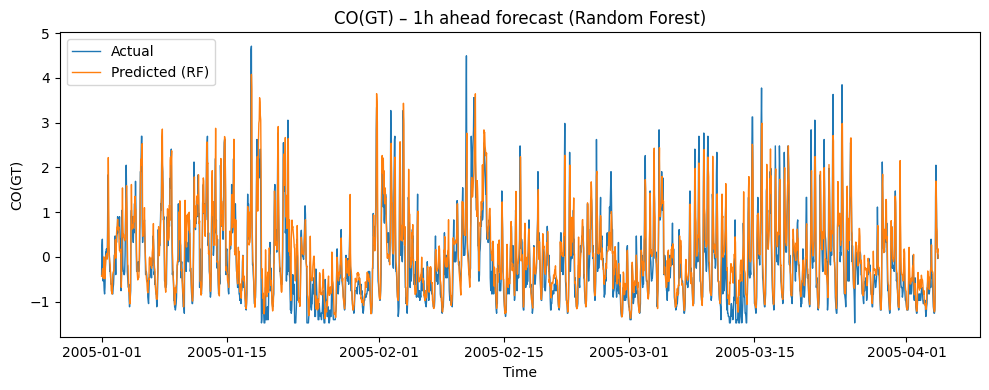

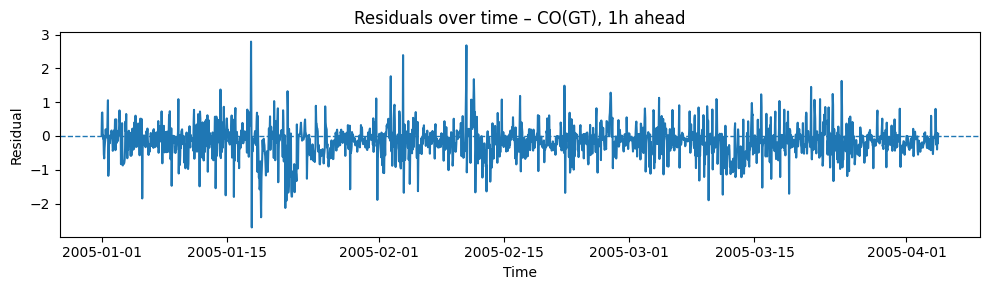

In [11]:
import matplotlib.pyplot as plt

target = "CO(GT)"
h = 1

X_train, y_train, _ = make_supervised(train, target, h, feature_cols)
X_test,  y_test,  y_naive_test = make_supervised(test,  target, h, feature_cols)

rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

timestamps_test = test.loc[X_test.index, "DateTime"]

# 1. Actual vs predicted over time
plt.figure(figsize=(10,4))
plt.plot(timestamps_test, y_test, label="Actual", linewidth=1)
plt.plot(timestamps_test, y_pred, label="Predicted (RF)", linewidth=1)
plt.xlabel("Time")
plt.ylabel(target)
plt.title(f"{target} – {h}h ahead forecast (Random Forest)")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Residuals over time
residuals = y_test - y_pred
plt.figure(figsize=(10,3))
plt.plot(timestamps_test, residuals)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title(f"Residuals over time – {target}, {h}h ahead")
plt.tight_layout()
plt.show()
